# 13. Regresion diagnostica visible de determinantes

Flujo activo: base interpretable del notebook 12 -> variables seleccionadas -> particion por hogares -> preprocesamiento ajustado con entrenamiento -> regresiones y diagnosticos -> exportacion opcional.

Limites: diagnostico exploratorio, sin seleccion automatica, sin stepwise, sin regresion reducida, sin PCR, sin deflactores, sin JKn y sin inferencia formal. Las variables se mantienen inicialmente completas para revision conjunta.


## Mapa de secciones requeridas

1. Proposito y limites del analisis.
2. Configuracion.
3. Rutas.
4. Lectura de base interpretable de notebook 12.
5. Validacion de anio, universo, edad, target positivo, llaves y variables requeridas.
6. Lista de variables candidatas, seleccionadas y pendientes.
7. Particion por hogares y verificacion de interseccion vacia.
8. Preparacion categorica con reglas visibles.
9. Encoder ajustado unicamente con entrenamiento.
10. Transformacion de entrenamiento y validacion.
11. Categorias de referencia y categorias no vistas.
12. Construccion de X_train, X_valid, y_train y y_valid.
13. Validacion de alineacion y filtracion.
14. Ajuste OLS nominal.
15. Predicciones nominales.
16. Metricas nominales.
17. Tabla de coeficientes.
18. Ajuste OLS con log(target).
19. Predicciones y metricas logaritmicas.
20. Diagnosticos de residuos.
21. Leverage y distancia de Cook.
22. Rango, constantes y duplicados de la matriz.
23. VIF por columna.
24. GVIF por variable original.
25. Construccion visible de la matriz especifica para PCA.
26. Ajuste del PCA con entrenamiento.
27. Transformacion de validacion.
28. Varianza explicada, scores, coeficientes y correlaciones con scores.
29. Scree plot y varianza acumulada.
30. Visualizaciones de cargas.
31. Ajuste del arbol diagnostico.
32. Metricas del arbol.
33. Importancia por impureza.
34. Permutacion conjunta por variable original en validacion.
35. Tabla de revision por variable.
36. Decisiones pendientes.
37. Exportacion opcional final.


## 1. Configuracion e imports


In [1]:
from __future__ import annotations
import json, math, sys
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

ANIO_ANALISIS = 2024
ANIOS_VALIDOS = (2018, 2020, 2022, 2024)
EDAD_MINIMA = 18
TARGET = "ingreso_persona_laboral_negocio_tri"
CRITERIO_STEPWISE = None
EJECUTAR_SELECCION = False
EXPORTAR_RESULTADOS = True
RANDOM_STATE = 20240914
TRAIN_FRAC = 0.80
TREE_MAX_DEPTH = 5
TREE_MIN_SAMPLES_LEAF = 0.01
PERMUTATION_REPEATS = 10
ESPECIFICACION = "diagnostico_inicial"

if ANIO_ANALISIS not in ANIOS_VALIDOS:
    raise ValueError(f"ANIO_ANALISIS debe estar en {ANIOS_VALIDOS}; recibido: {ANIO_ANALISIS}.")
if EDAD_MINIMA <= 0:
    raise ValueError(f"EDAD_MINIMA debe ser positiva; recibida: {EDAD_MINIMA}.")
if TARGET != "ingreso_persona_laboral_negocio_tri":
    raise ValueError("El target aprobado para esta etapa es ingreso_persona_laboral_negocio_tri.")
if CRITERIO_STEPWISE is not None or EJECUTAR_SELECCION:
    raise ValueError("La seleccion automatica permanece desactivada en este diagnostico.")
if not 0 < TRAIN_FRAC < 1:
    raise ValueError("TRAIN_FRAC debe estar entre 0 y 1.")

configuracion_efectiva = pd.DataFrame([
    {"parametro":"ANIO_ANALISIS", "valor":ANIO_ANALISIS},
    {"parametro":"ANIOS_VALIDOS", "valor":ANIOS_VALIDOS},
    {"parametro":"EDAD_MINIMA", "valor":EDAD_MINIMA},
    {"parametro":"TARGET", "valor":TARGET},
    {"parametro":"CRITERIO_STEPWISE", "valor":CRITERIO_STEPWISE},
    {"parametro":"EJECUTAR_SELECCION", "valor":EJECUTAR_SELECCION},
    {"parametro":"EXPORTAR_RESULTADOS", "valor":EXPORTAR_RESULTADOS},
    {"parametro":"RANDOM_STATE", "valor":RANDOM_STATE},
    {"parametro":"TRAIN_FRAC", "valor":TRAIN_FRAC},
    {"parametro":"TREE_MAX_DEPTH", "valor":TREE_MAX_DEPTH},
    {"parametro":"TREE_MIN_SAMPLES_LEAF", "valor":TREE_MIN_SAMPLES_LEAF},
    {"parametro":"PERMUTATION_REPEATS", "valor":PERMUTATION_REPEATS},
])
configuracion_efectiva


,parametro,valor
0,ANIO_ANALISIS,2024
1,ANIOS_VALIDOS,"(2018, 2020, 2022, 2024)"
2,EDAD_MINIMA,18
3,TARGET,ingreso_persona_laboral_negocio_tri
4,CRITERIO_STEPWISE,None
5,EJECUTAR_SELECCION,False
6,EXPORTAR_RESULTADOS,True
7,RANDOM_STATE,20240914
8,TRAIN_FRAC,0.8
9,TREE_MAX_DEPTH,5


## 2. Rutas y helpers acotados


In [2]:
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
while not (PROJECT_ROOT / "README.md").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "README.md").exists():
    raise FileNotFoundError("No se pudo localizar la raiz del proyecto.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features.preparacion_determinantes import (
    CATEGORICAL_PREDICTORS, CONTINUOUS_PREDICTORS, HOUSEHOLD_KEY_COLS,
    KEY_COLS, LOG_TARGET, METADATA_COLS, PreparationConfig,
    prepare_categorical_for_matrix,
)
from src.analysis.regresion_diagnostico import build_train_encoder, transform_regression_matrix
from src.models.regresion_diagnostico import (
    aggregate_column_importance, coefficient_table, compute_gvif,
    compute_vif_auxiliary, fit_decision_tree, fit_ols, influence_diagnostics,
    matrix_dependency_diagnostics, permutation_importance_by_block,
    predict_ols, regression_metrics, verify_vif_gvif_examples,
)

PREP_CONFIG = PreparationConfig.from_root(PROJECT_ROOT, year=ANIO_ANALISIS, min_age=EDAD_MINIMA, valid_years=ANIOS_VALIDOS)
BASE_PATH = PREP_CONFIG.processed_dir / f"base_interpretable_personas_{ANIO_ANALISIS}.csv.gz"
TABLE_DIR = PROJECT_ROOT / "reports" / "tables" / "regresion_diagnostico" / str(ANIO_ANALISIS) / ESPECIFICACION
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures" / "regresion_diagnostico" / str(ANIO_ANALISIS) / ESPECIFICACION
LOCAL_DIR = PROJECT_ROOT / "data" / "processed" / "regresion_diagnostico" / str(ANIO_ANALISIS) / ESPECIFICACION

rutas_configuradas = pd.DataFrame([
    {"tipo":"entrada_base_interpretable", "ruta":str(BASE_PATH)},
    {"tipo":"salida_tablas_versionadas", "ruta":str(TABLE_DIR)},
    {"tipo":"salida_figuras_versionadas", "ruta":str(FIGURE_DIR)},
    {"tipo":"salida_local_fuera_git", "ruta":str(LOCAL_DIR)},
])
rutas_configuradas


,tipo,ruta
0,entrada_base_interpretable,C:\Users\lucia\OneDrive\Escritorio\Fer\inegi-i...
1,salida_tablas_versionadas,C:\Users\lucia\OneDrive\Escritorio\Fer\inegi-i...
2,salida_figuras_versionadas,C:\Users\lucia\OneDrive\Escritorio\Fer\inegi-i...
3,salida_local_fuera_git,C:\Users\lucia\OneDrive\Escritorio\Fer\inegi-i...


## 3. Variables candidatas, seleccionadas, pendientes y exclusiones


In [3]:
variables_candidatas = [
    "edad", "n_trabajos", "horas_trabajos_total", "tot_integ", "menores", "p65mas",
    "sexo_desc", "nivelaprob_desc", "region_banxico", "tam_loc_desc", "parentesco_desc",
    "hablaind_desc", "segsoc_desc", "subor_principal_desc", "contrato_principal_desc",
    "sexo_jefe_desc", "educa_jefe_desc",
]
variables_seleccionadas = variables_candidatas.copy()
variables_pendientes = {
    "tam_emp_principal_desc":"Pendiente por dependencia estructural potencial con subordinacion; conservar para revision.",
    "est_socio_desc":"Contexto socioeconomico; requiere decision sustantiva antes de entrar como predictor.",
}
exclusiones_tecnicas = [
    "target, log_target y componentes monetarios del ingreso objetivo",
    "llaves e identificadores de persona/hogar",
    "factor, factor_hogar, est_dis y upm como metadata",
    "deflactores, variables reales y JKn de etapas deprecadas",
    "variables pendientes sin decision metodologica aprobada",
]
if variables_candidatas != list(CONTINUOUS_PREDICTORS) + list(CATEGORICAL_PREDICTORS):
    raise ValueError("Las 17 candidatas visibles no coinciden con la especificacion vigente del modulo.")
fuera_catalogo = sorted(set(variables_seleccionadas) - set(variables_candidatas))
if fuera_catalogo:
    raise ValueError("variables_seleccionadas debe ser subconjunto de variables_candidatas: " + ", ".join(fuera_catalogo))
variables_excluidas_manual = [v for v in variables_candidatas if v not in variables_seleccionadas]

tabla_variables = pd.DataFrame([
    {"variable":v, "tipo":"continua" if v in CONTINUOUS_PREDICTORS else "categorica", "estado":"seleccionada" if v in variables_seleccionadas else "excluida_manual"}
    for v in variables_candidatas
])
display(tabla_variables)
display(pd.DataFrame([{"variable":k, "motivo":v} for k, v in variables_pendientes.items()]))
display(pd.DataFrame({"exclusion_tecnica":exclusiones_tecnicas}))


,variable,tipo,estado
0,edad,continua,seleccionada
1,n_trabajos,continua,seleccionada
2,horas_trabajos_total,continua,seleccionada
3,tot_integ,continua,seleccionada
4,menores,continua,seleccionada
5,p65mas,continua,seleccionada
6,sexo_desc,categorica,seleccionada
7,nivelaprob_desc,categorica,seleccionada
8,region_banxico,categorica,seleccionada
9,tam_loc_desc,categorica,seleccionada


,variable,motivo
0,tam_emp_principal_desc,Pendiente por dependencia estructural potencia...
1,est_socio_desc,Contexto socioeconomico; requiere decision sus...


,exclusion_tecnica
0,"target, log_target y componentes monetarios de..."
1,llaves e identificadores de persona/hogar
2,"factor, factor_hogar, est_dis y upm como metadata"
3,"deflactores, variables reales y JKn de etapas ..."
4,variables pendientes sin decision metodologica...


## 4. Lectura de base interpretable del notebook 12


In [4]:
if not BASE_PATH.exists():
    raise FileNotFoundError(f"No existe {BASE_PATH}. Ejecuta primero el notebook 12 con el mismo ANIO_ANALISIS.")
base_determinantes = pd.read_csv(BASE_PATH, low_memory=False)
pd.DataFrame([{"objeto":"base_determinantes", "filas":len(base_determinantes), "columnas":base_determinantes.shape[1], "ruta":str(BASE_PATH)}])


,objeto,filas,columnas,ruta
0,base_determinantes,141579,39,C:\Users\lucia\OneDrive\Escritorio\Fer\inegi-i...


In [26]:
base_determinantes

,anio,folioviv,foliohog,numren,ingreso_persona_laboral_negocio_tri,log_ingreso_persona_laboral_negocio_tri,edad,n_trabajos,horas_trabajos_total,tot_integ,...,percep_ing,perc_ocupa,factor,factor_hogar,est_dis,upm,cve_ent,entidad,cve_mun,municipio
0,2024,100001901,1,1,78789.11,11.274530,32,1.0,48.0,4,...,2,2,207,207,1,1,1,Aguascalientes,1,Aguascalientes
1,2024,100001901,1,2,31157.59,10.346813,24,1.0,45.0,4,...,2,2,207,207,1,1,1,Aguascalientes,1,Aguascalientes
2,2024,100001902,1,1,56739.12,10.946219,48,1.0,48.0,4,...,2,2,207,207,1,1,1,Aguascalientes,1,Aguascalientes
3,2024,100001902,1,3,29347.82,10.286974,22,1.0,48.0,4,...,2,2,207,207,1,1,1,Aguascalientes,1,Aguascalientes
4,2024,100001904,1,1,11861.40,9.381045,60,2.0,30.0,2,...,2,2,207,207,1,1,1,Aguascalientes,1,Aguascalientes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141574,2024,3260593816,1,1,34745.88,10.455816,50,2.0,80.0,5,...,3,2,183,183,680,10593,32,Zacatecas,52,Villa Garcia
141575,2024,3260593816,1,3,8065.57,8.995360,21,1.0,55.0,5,...,3,2,183,183,680,10593,32,Zacatecas,52,Villa Garcia
141576,2024,3260593817,1,2,3344.26,8.115001,54,1.0,168.0,2,...,1,1,183,183,680,10593,32,Zacatecas,52,Villa Garcia
141577,2024,3260593818,1,1,7131.14,8.872226,63,1.0,24.0,2,...,2,2,183,183,680,10593,32,Zacatecas,52,Villa Garcia


## 5. Validacion de anio, universo, target, llaves y variables


In [5]:
columnas_requeridas = list(dict.fromkeys(KEY_COLS + HOUSEHOLD_KEY_COLS + ["edad", TARGET, LOG_TARGET] + variables_candidatas + list(variables_pendientes) + list(METADATA_COLS)))
faltantes_base = sorted(set(columnas_requeridas) - set(base_determinantes.columns))
if faltantes_base:
    raise KeyError("Faltan columnas requeridas en la base interpretable: " + ", ".join(faltantes_base))
validaciones_entrada = pd.DataFrame([
    {"validacion":"anio_unico", "valor":sorted(base_determinantes["anio"].dropna().astype(int).unique().tolist()), "estado":"ok" if base_determinantes["anio"].eq(ANIO_ANALISIS).all() else "revisar"},
    {"validacion":"edad_minima", "valor":float(pd.to_numeric(base_determinantes["edad"], errors="coerce").min()), "estado":"ok" if pd.to_numeric(base_determinantes["edad"], errors="coerce").ge(EDAD_MINIMA).all() else "revisar"},
    {"validacion":"target_positivo", "valor":float(pd.to_numeric(base_determinantes[TARGET], errors="coerce").min()), "estado":"ok" if pd.to_numeric(base_determinantes[TARGET], errors="coerce").gt(0).all() else "revisar"},
    {"validacion":"llave_persona_unica", "valor":int(base_determinantes.duplicated(KEY_COLS).sum()), "estado":"ok" if int(base_determinantes.duplicated(KEY_COLS).sum()) == 0 else "revisar"},
    {"validacion":"columnas_requeridas", "valor":len(columnas_requeridas), "estado":"ok"},
])
if not validaciones_entrada["estado"].isin(["ok", "informativo"]).all():
    display(validaciones_entrada)
    raise ValueError("La base interpretable no cumple las validaciones de entrada.")
validaciones_entrada


,validacion,valor,estado
0,anio_unico,[2024],ok
1,edad_minima,18.0,ok
2,target_positivo,2.93,ok
3,llave_persona_unica,0,ok
4,columnas_requeridas,33,ok


## 6. Particion por hogares


In [6]:
hogares = base_determinantes[HOUSEHOLD_KEY_COLS].drop_duplicates().reset_index(drop=True)
rng = np.random.default_rng(RANDOM_STATE)
orden = rng.permutation(len(hogares))
n_train = int(math.floor(len(hogares) * TRAIN_FRAC))
particion = np.array(["validacion"] * len(hogares), dtype=object)
particion[orden[:n_train]] = "entrenamiento"
hogares = hogares.copy()
hogares["particion"] = particion
base_particionada = base_determinantes.merge(hogares, on=HOUSEHOLD_KEY_COLS, how="left", validate="many_to_one")
train = base_particionada.loc[base_particionada["particion"].eq("entrenamiento")].reset_index(drop=True)
valid = base_particionada.loc[base_particionada["particion"].eq("validacion")].reset_index(drop=True)

hogares_train = set(map(tuple, hogares.loc[hogares["particion"].eq("entrenamiento"), HOUSEHOLD_KEY_COLS].to_numpy()))
hogares_valid = set(map(tuple, hogares.loc[hogares["particion"].eq("validacion"), HOUSEHOLD_KEY_COLS].to_numpy()))
hogares_compartidos = len(hogares_train & hogares_valid)
resumen_particion = base_particionada.groupby("particion").agg(personas=("particion", "size")).reset_index().merge(hogares.groupby("particion").size().rename("hogares").reset_index(), on="particion", how="left")
resumen_particion["pct_personas"] = resumen_particion["personas"] / len(base_particionada)
resumen_particion["pct_hogares"] = resumen_particion["hogares"] / len(hogares)
validacion_particion = pd.DataFrame([
    {"validacion":"sin_hogares_compartidos", "valor":hogares_compartidos, "estado":"ok" if hogares_compartidos == 0 else "revisar"},
    {"validacion":"personas_con_particion", "valor":int(base_particionada["particion"].notna().sum()), "estado":"ok" if base_particionada["particion"].notna().all() else "revisar"},
])
display(resumen_particion)
display(validacion_particion)


,particion,personas,hogares,pct_personas,pct_hogares
0,entrenamiento,113173,64697,0.799363,0.799993
1,validacion,28406,16175,0.200637,0.200007


,validacion,valor,estado
0,sin_hogares_compartidos,0,ok
1,personas_con_particion,141579,ok


## 7. Preparacion categorica y encoder ajustado con entrenamiento


In [7]:
categorias_train_preparadas = prepare_categorical_for_matrix(train)
categorias_valid_preparadas = prepare_categorical_for_matrix(valid)
encoder = build_train_encoder(train, variables_seleccionadas)
referencias_entrenamiento = pd.DataFrame([
    {"variable_original":v, "referencia":r, "n_referencia_entrenamiento":int(categorias_train_preparadas[v].eq(r).sum()), "n_referencia_validacion":int(categorias_valid_preparadas[v].eq(r).sum())}
    for v, r in encoder["references"].items()
])
categorias_encoder = pd.DataFrame([
    {"variable_original":v, "categoria_entrenamiento":cat, "es_referencia":cat == encoder["references"][v]}
    for v, cats in encoder["categories"].items() for cat in cats
])
display(referencias_entrenamiento)
display(categorias_encoder.head(40))


,variable_original,referencia,n_referencia_entrenamiento,n_referencia_validacion
0,sexo_desc,Hombre,65851,16453
1,nivelaprob_desc,Ninguno,3313,832
2,region_banxico,Centro,28364,7264
3,tam_loc_desc,Localidades con 100 000 y más habitantes,43685,10859
4,parentesco_desc,Jefe(a),54428,13607
5,hablaind_desc,No,104412,26170
6,segsoc_desc,No,46616,11662
7,subor_principal_desc,No,25055,6390
8,contrato_principal_desc,No,42131,10565
9,sexo_jefe_desc,Hombre,80468,20107


,variable_original,categoria_entrenamiento,es_referencia
0,sexo_desc,Hombre,True
1,sexo_desc,Mujer,False
2,nivelaprob_desc,Doctorado,False
3,nivelaprob_desc,Especialidad,False
4,nivelaprob_desc,Estudios técnicos o comerciales,False
5,nivelaprob_desc,Licenciatura o Ingeniería (profesional),False
6,nivelaprob_desc,Maestría,False
7,nivelaprob_desc,Ninguno,True
8,nivelaprob_desc,Normal,False
9,nivelaprob_desc,Preescolar o kínder,False


## 8. Transformacion de entrenamiento y validacion


In [11]:
X_train, column_info, categorias_no_vistas_train = transform_regression_matrix(train, encoder)
X_valid, _, categorias_no_vistas_valid = transform_regression_matrix(valid, encoder)
categorias_no_vistas = pd.concat([categorias_no_vistas_train.assign(particion="entrenamiento"), categorias_no_vistas_valid.assign(particion="validacion")], ignore_index=True)
if list(X_train.columns) != list(X_valid.columns):
    raise ValueError("X_train y X_valid no tienen la misma estructura aprendida desde entrenamiento.")
column_info = column_info.copy()
column_info["n_entrenamiento"] = [int(X_train[c].sum()) if c in X_train.columns and set(X_train[c].dropna().unique()).issubset({0, 1}) else len(X_train) for c in column_info["columna_matriz"]]
column_info["n_validacion"] = [int(X_valid[c].sum()) if c in X_valid.columns and set(X_valid[c].dropna().unique()).issubset({0, 1}) else len(X_valid) for c in column_info["columna_matriz"]]
display(pd.DataFrame([{"objeto":"X_train", "filas":X_train.shape[0], "columnas":X_train.shape[1]}, {"objeto":"X_valid", "filas":X_valid.shape[0], "columnas":X_valid.shape[1]}]))
display(categorias_no_vistas)


,objeto,filas,columnas
0,X_train,113173,66
1,X_valid,28406,66


,variable_original,categoria_no_vista_en_entrenamiento,n,particion
0,parentesco_desc,Hijo(a) de crianza,1,validacion


## 9. Construccion de X/y y validacion de filtracion


In [12]:
y_train = pd.to_numeric(train[TARGET], errors="coerce")
y_valid = pd.to_numeric(valid[TARGET], errors="coerce")
y_train_log = np.log(y_train)
y_valid_log = np.log(y_valid)
columnas_prohibidas = set(KEY_COLS + HOUSEHOLD_KEY_COLS + [TARGET, LOG_TARGET] + list(METADATA_COLS) + list(variables_pendientes))
validaciones_matriz = pd.DataFrame([
    {"validacion":"alineacion_train", "valor":len(X_train) == len(y_train) == len(train), "estado":"ok" if len(X_train) == len(y_train) == len(train) else "revisar"},
    {"validacion":"alineacion_valid", "valor":len(X_valid) == len(y_valid) == len(valid), "estado":"ok" if len(X_valid) == len(y_valid) == len(valid) else "revisar"},
    {"validacion":"sin_columnas_prohibidas_en_X", "valor":sorted(set(X_train.columns) & columnas_prohibidas), "estado":"ok" if not (set(X_train.columns) & columnas_prohibidas) else "revisar"},
    {"validacion":"mismas_columnas_train_valid", "valor":list(X_train.columns) == list(X_valid.columns), "estado":"ok" if list(X_train.columns) == list(X_valid.columns) else "revisar"},
    {"validacion":"sin_hogares_compartidos", "valor":hogares_compartidos, "estado":"ok" if hogares_compartidos == 0 else "revisar"},
])
if not validaciones_matriz["estado"].isin(["ok", "informativo"]).all():
    display(validaciones_matriz)
    raise ValueError("Revisar validaciones de matriz antes de modelar.")
validaciones_matriz


,validacion,valor,estado
0,alineacion_train,True,ok
1,alineacion_valid,True,ok
2,sin_columnas_prohibidas_en_X,[],ok
3,mismas_columnas_train_valid,True,ok
4,sin_hogares_compartidos,0,ok


## 10. OLS nominal: ajuste, predicciones, metricas y coeficientes


In [13]:
modelo_ols_nominal = fit_ols(X_train, y_train, scale_name="ingreso_nominal")
pred_train_nominal = predict_ols(modelo_ols_nominal, X_train)
pred_valid_nominal = predict_ols(modelo_ols_nominal, X_valid)
predicciones = pd.DataFrame({"particion":["entrenamiento"]*len(train) + ["validacion"]*len(valid), "y_observado":pd.concat([y_train, y_valid], ignore_index=True), "pred_ingreso_nominal":np.concatenate([pred_train_nominal, pred_valid_nominal])})
metricas_nominal = pd.DataFrame([regression_metrics(y_train, pred_train_nominal, scale_name="ingreso_nominal", split="entrenamiento"), regression_metrics(y_valid, pred_valid_nominal, scale_name="ingreso_nominal", split="validacion")])
fit_nominal = pd.DataFrame([{"escala":"ingreso_nominal", "n_obs":modelo_ols_nominal["n_obs"], "n_params":modelo_ols_nominal["n_params"], "rango":modelo_ols_nominal["rank"], "r2":modelo_ols_nominal["r2"], "r2_ajustado":modelo_ols_nominal["adj_r2"], "aic":modelo_ols_nominal["aic"], "bic":modelo_ols_nominal["bic"]}])
tabla_coeficientes_nominal = coefficient_table(modelo_ols_nominal, list(X_train.columns), column_info)
display(fit_nominal)
display(metricas_nominal)
display(tabla_coeficientes_nominal.head(30))


,escala,n_obs,n_params,rango,r2,r2_ajustado,aic,bic
0,ingreso_nominal,113173,67,67,0.069968,0.069425,2.511094e+06,2.511739e+06


,escala,particion,n,mae,rmse
0,ingreso_nominal,entrenamiento,113173,15781.401464,65739.667699
1,ingreso_nominal,validacion,28406,15827.766091,41410.432414


,escala,columna_matriz,variable_original,categoria,referencia_variable,coeficiente,nota
0,ingreso_nominal,intercepto,intercepto,,,18620.228192,Intercepto de OLS no ponderado.
1,ingreso_nominal,edad,edad,,,55.385015,Coeficiente en unidades de la escala indicada;...
2,ingreso_nominal,n_trabajos,n_trabajos,,,-232.848255,Coeficiente en unidades de la escala indicada;...
3,ingreso_nominal,horas_trabajos_total,horas_trabajos_total,,,307.799468,Coeficiente en unidades de la escala indicada;...
4,ingreso_nominal,tot_integ,tot_integ,,,205.851854,Coeficiente en unidades de la escala indicada;...
5,ingreso_nominal,menores,menores,,,130.840911,Coeficiente en unidades de la escala indicada;...
6,ingreso_nominal,p65mas,p65mas,,,-1764.409808,Coeficiente en unidades de la escala indicada;...
7,ingreso_nominal,sexo_desc__mujer,sexo_desc,Mujer,Hombre,-8145.745029,Coeficiente en unidades de la escala indicada;...
8,ingreso_nominal,nivelaprob_desc__doctorado,nivelaprob_desc,Doctorado,Ninguno,51525.880351,Coeficiente en unidades de la escala indicada;...
9,ingreso_nominal,nivelaprob_desc__especialidad,nivelaprob_desc,Especialidad,Ninguno,49200.461046,Coeficiente en unidades de la escala indicada;...


## 11. OLS con log(target): ajuste, predicciones y metricas


In [14]:
modelo_ols_log = fit_ols(X_train, y_train_log, scale_name="log_ingreso")
pred_train_log = predict_ols(modelo_ols_log, X_train)
pred_valid_log = predict_ols(modelo_ols_log, X_valid)
predicciones["pred_log_ingreso"] = np.concatenate([pred_train_log, pred_valid_log])
metricas_log = pd.DataFrame([regression_metrics(y_train_log, pred_train_log, scale_name="log_ingreso", split="entrenamiento"), regression_metrics(y_valid_log, pred_valid_log, scale_name="log_ingreso", split="validacion")])
fit_log = pd.DataFrame([{"escala":"log_ingreso", "n_obs":modelo_ols_log["n_obs"], "n_params":modelo_ols_log["n_params"], "rango":modelo_ols_log["rank"], "r2":modelo_ols_log["r2"], "r2_ajustado":modelo_ols_log["adj_r2"], "aic":modelo_ols_log["aic"], "bic":modelo_ols_log["bic"]}])
tabla_coeficientes_log = coefficient_table(modelo_ols_log, list(X_train.columns), column_info)
metricas_regresion = pd.concat([metricas_nominal, metricas_log], ignore_index=True)
tabla_coeficientes = pd.concat([tabla_coeficientes_nominal, tabla_coeficientes_log], ignore_index=True)
display(fit_log)
display(metricas_log)


,escala,n_obs,n_params,rango,r2,r2_ajustado,aic,bic
0,log_ingreso,113173,67,67,0.459981,0.459665,-27309.210766,-26663.553681


,escala,particion,n,mae,rmse
0,log_ingreso,entrenamiento,113173,0.619186,0.885817
1,log_ingreso,validacion,28406,0.631046,0.903270


## 12. Residuos, leverage y distancia de Cook


In [15]:
diagnosticos_residuos, observaciones_influyentes = influence_diagnostics(X_train, y_train, modelo_ols_nominal, top_n=25)
residuos_train = pd.DataFrame({"y":y_train, "ajustado_ingreso_nominal":modelo_ols_nominal["fitted"], "residuo_ingreso_nominal":modelo_ols_nominal["residuals"]})
display(diagnosticos_residuos)
display(observaciones_influyentes.head(10))


,metrica,min,p50,p90,p95,p99,max
0,residuo,-9.438122e+04,-3.371620e+03,18683.011354,33592.555220,100180.278957,1.694914e+07
1,residuo_abs,1.164153e-10,1.007246e+04,30468.041825,41566.414792,100180.278957,1.694914e+07
2,leverage,1.064640e-04,2.924587e-04,0.000742,0.001068,0.003620,1.000000e+00
3,cooks_distance,1.062730e-16,1.135959e-07,0.000001,0.000003,0.000021,1.334183e+01


,rank_cooks_sin_identificadores,y,ajustado,residuo,leverage,cooks_distance
0,1,11249.98,11249.980000,4.365575e-10,1.000000,13.341829
1,2,1076.08,1076.080000,3.474270e-10,1.000000,8.450057
2,3,17021739.12,72598.469055,1.694914e+07,0.000225,0.223500
3,4,3145054.93,66755.155218,3.078300e+06,0.002813,0.092518
4,5,5978481.63,45727.284400,5.932754e+06,0.000525,0.063815
5,6,4426229.50,65086.799000,4.361143e+06,0.000292,0.019151
6,7,809409.83,80461.748732,7.289481e+05,0.003726,0.006885
7,8,2785304.34,68018.487677,2.717286e+06,0.000252,0.006438
8,9,1864956.52,33298.456185,1.831658e+06,0.000492,0.005706
9,10,2211983.60,37713.984388,2.174270e+06,0.000330,0.005383


## 13. Rango, constantes, duplicados, VIF y GVIF


In [16]:
dependencia_matriz, detalle_dependencia_matriz = matrix_dependency_diagnostics(X_train)
tabla_vif = compute_vif_auxiliary(X_train)
tabla_gvif = compute_gvif(X_train, column_info)
validacion_vif_gvif = verify_vif_gvif_examples()
display(dependencia_matriz)
display(detalle_dependencia_matriz)
display(tabla_vif.head(20))
display(tabla_gvif.head(20))
display(validacion_vif_gvif)


,metrica,valor
0,filas,113173
1,columnas,66
2,rango_sin_intercepto,66
3,rango_con_intercepto,67
4,constantes,0
5,duplicados_exactos,0


,columna,valor_constante,tipo,columna_a,columna_b


,columna_matriz,r2_auxiliar_con_intercepto,vif,estado
0,contrato_principal_desc__no_aplica_sin_contrat...,0.971991,35.702183,ok
1,subor_principal_desc__si,0.971909,35.598373,ok
2,nivelaprob_desc__secundaria,0.921333,12.711750,ok
3,nivelaprob_desc__licenciatura_o_ingenieria_pro...,0.915996,11.904224,ok
4,nivelaprob_desc__preparatoria_o_bachillerato,0.915989,11.903265,ok
5,nivelaprob_desc__primaria,0.891429,9.210602,ok
6,educa_jefe_desc__secundaria_completa,0.875000,7.999995,ok
7,educa_jefe_desc__preparatoria_completa,0.829249,5.856483,ok
8,educa_jefe_desc__profesional_completa,0.822213,5.624711,ok
9,educa_jefe_desc__primaria_completa,0.808590,5.224385,ok


,variable_original,df_bloque,gvif,gvif_ajustado,estado,nota
0,subor_principal_desc,2,57.105250,2.748964,ok,GVIF por bloque; no comparar GVIF ajustado con...
1,contrato_principal_desc,2,49.486862,2.652299,ok,GVIF por bloque; no comparar GVIF ajustado con...
2,edad,1,2.529877,1.590559,ok,GVIF por bloque; no comparar GVIF ajustado con...
3,tot_integ,1,2.138425,1.462336,ok,GVIF por bloque; no comparar GVIF ajustado con...
4,menores,1,2.014427,1.419305,ok,GVIF por bloque; no comparar GVIF ajustado con...
5,n_trabajos,1,1.698079,1.303104,ok,GVIF por bloque; no comparar GVIF ajustado con...
6,segsoc_desc,1,1.560358,1.249143,ok,GVIF por bloque; no comparar GVIF ajustado con...
7,p65mas,1,1.527542,1.235938,ok,GVIF por bloque; no comparar GVIF ajustado con...
8,sexo_desc,1,1.469256,1.212129,ok,GVIF por bloque; no comparar GVIF ajustado con...
9,horas_trabajos_total,1,1.454942,1.206210,ok,GVIF por bloque; no comparar GVIF ajustado con...


,prueba,valor_a,valor_b,diferencia_abs,estado
0,gvif_un_df_igual_vif,1030.859375,1030.859375,3.810783e-10,ok
1,gvif_bloque_multicolumna_finito,29.208333,2.324752,NaN,ok


## 14. Matriz visible para PCA


In [17]:
continuas_pca = [c for c in X_train.columns if c in CONTINUOUS_PREDICTORS]
dummies_pca = [c for c in X_train.columns if c not in continuas_pca]
medias_continuas_train = X_train[continuas_pca].mean()
desv_continuas_train = X_train[continuas_pca].std(ddof=0).replace(0, np.nan)
if desv_continuas_train.isna().any():
    raise ValueError("Hay continuas constantes en entrenamiento; revisar antes de PCA.")
medias_dummies_train = X_train[dummies_pca].mean() if dummies_pca else pd.Series(dtype=float)
matriz_pca_train = pd.DataFrame(index=X_train.index)
matriz_pca_valid = pd.DataFrame(index=X_valid.index)
matriz_pca_train[continuas_pca] = (X_train[continuas_pca] - medias_continuas_train) / desv_continuas_train
matriz_pca_valid[continuas_pca] = (X_valid[continuas_pca] - medias_continuas_train) / desv_continuas_train
if dummies_pca:
    matriz_pca_train[dummies_pca] = X_train[dummies_pca] - medias_dummies_train
    matriz_pca_valid[dummies_pca] = X_valid[dummies_pca] - medias_dummies_train
matriz_pca_train = matriz_pca_train[list(X_train.columns)]
matriz_pca_valid = matriz_pca_valid[list(X_train.columns)]
parametros_pca = pd.concat([
    pd.DataFrame({"columna_matriz":continuas_pca, "media_entrenamiento":medias_continuas_train.values, "escala_entrenamiento":desv_continuas_train.values, "tratamiento":"z_score_continua"}),
    pd.DataFrame({"columna_matriz":dummies_pca, "media_entrenamiento":medias_dummies_train.reindex(dummies_pca).values, "escala_entrenamiento":1.0, "tratamiento":"dummy_centrada"}),
], ignore_index=True)
display(pd.DataFrame([{"objeto":"matriz_pca_train", "filas":matriz_pca_train.shape[0], "columnas":matriz_pca_train.shape[1]}, {"objeto":"matriz_pca_valid", "filas":matriz_pca_valid.shape[0], "columnas":matriz_pca_valid.shape[1]}]))
display(parametros_pca.head(20))


,objeto,filas,columnas
0,matriz_pca_train,113173,66
1,matriz_pca_valid,28406,66


,columna_matriz,media_entrenamiento,escala_entrenamiento,tratamiento
0,edad,40.995388,14.382962,z_score_continua
1,n_trabajos,1.055375,0.355191,z_score_continua
2,horas_trabajos_total,43.736819,19.881350,z_score_continua
3,tot_integ,4.009941,1.883994,z_score_continua
4,menores,0.699319,0.958604,z_score_continua
5,p65mas,0.259408,0.561585,z_score_continua
6,sexo_desc__mujer,0.418139,1.000000,dummy_centrada
7,nivelaprob_desc__doctorado,0.002978,1.000000,dummy_centrada
8,nivelaprob_desc__especialidad,0.002518,1.000000,dummy_centrada
9,nivelaprob_desc__estudios_tecnicos_o_comerciales,0.024502,1.000000,dummy_centrada


## 15. PCA ajustado con entrenamiento y transformacion de validacion


In [18]:
modelo_pca = PCA(svd_solver="full")
scores_pca_train = modelo_pca.fit_transform(matriz_pca_train)
scores_pca_valid = modelo_pca.transform(matriz_pca_valid)
scores_pca = {"entrenamiento":pd.DataFrame(scores_pca_train, columns=[f"PC{i+1}" for i in range(scores_pca_train.shape[1])]), "validacion":pd.DataFrame(scores_pca_valid, columns=[f"PC{i+1}" for i in range(scores_pca_valid.shape[1])])}
varianza_pca = pd.DataFrame({"componente":[f"PC{i+1}" for i in range(len(modelo_pca.explained_variance_ratio_))], "varianza_explicada":modelo_pca.explained_variance_ratio_, "varianza_acumulada":np.cumsum(modelo_pca.explained_variance_ratio_), "eigenvalue":modelo_pca.explained_variance_})
cargas_pca = pd.DataFrame(modelo_pca.components_.T, index=matriz_pca_train.columns, columns=[f"PC{i+1}" for i in range(modelo_pca.n_components_)]).reset_index(names="columna_matriz")
cargas_pca = cargas_pca.merge(column_info[["columna_matriz", "variable_original", "tipo"]], on="columna_matriz", how="left")
correlaciones_scores_target = pd.DataFrame([{"componente":c, "corr_spearman_target_train":float(scores_pca["entrenamiento"][c].corr(pd.Series(y_train), method="spearman")), "corr_spearman_log_target_train":float(scores_pca["entrenamiento"][c].corr(pd.Series(y_train_log), method="spearman"))} for c in scores_pca["entrenamiento"].columns])
display(varianza_pca.head(20))
display(cargas_pca.head(20))
display(correlaciones_scores_target.head(20))


,componente,varianza_explicada,varianza_acumulada,eigenvalue
0,PC1,0.176518,0.176518,1.831945
1,PC2,0.141510,0.318028,1.468623
2,PC3,0.122606,0.440634,1.272436
3,PC4,0.078729,0.519362,0.817066
4,PC5,0.062002,0.581365,0.643475
5,PC6,0.045546,0.626910,0.472686
6,PC7,0.036469,0.663379,0.378483
7,PC8,0.034107,0.697486,0.353972
8,PC9,0.028759,0.726246,0.298472
9,PC10,0.026247,0.752493,0.272396


,columna_matriz,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,...,PC59,PC60,PC61,PC62,PC63,PC64,PC65,PC66,variable_original,tipo
0,edad,-0.459235,-0.019431,0.490887,-0.425643,-0.413356,0.196922,0.051885,0.187890,0.028252,...,0.000271,0.000586,0.000014,0.000132,-1.276550e-05,2.559295e-05,2.868801e-05,-2.904480e-05,edad,continua
1,n_trabajos,0.050362,0.631905,0.283919,-0.191352,0.591249,0.302389,0.064844,0.028161,-0.026676,...,-0.000102,0.000025,-0.000004,0.000016,-5.252090e-07,7.013813e-06,-2.017401e-06,3.031272e-06,n_trabajos,continua
2,horas_trabajos_total,0.143533,0.674280,0.114680,0.206433,-0.479131,-0.379850,-0.091246,-0.082122,0.220534,...,0.000042,0.000072,-0.000002,0.000006,4.510796e-06,-1.249446e-05,2.262190e-06,-1.450963e-06,horas_trabajos_total,continua
3,tot_integ,0.571202,-0.195994,0.371029,0.090190,-0.039937,0.010290,0.135747,0.631104,0.178470,...,-0.000250,-0.000342,-0.000003,-0.000075,-8.868264e-06,1.632864e-08,-2.909318e-05,-3.249207e-05,tot_integ,continua
4,menores,0.591779,-0.151283,0.274862,-0.269687,-0.144222,0.160757,-0.179389,-0.581544,-0.137568,...,0.000118,0.000323,-0.000026,0.000072,-1.904956e-06,1.120550e-05,2.875941e-05,2.264537e-05,menores,continua
5,p65mas,-0.247600,-0.169136,0.597606,0.651553,0.118968,0.033296,0.027960,-0.293821,-0.015557,...,-0.000147,-0.000404,-0.000012,-0.000042,5.515575e-06,-1.004012e-05,3.502261e-06,2.415602e-06,p65mas,continua
6,sexo_desc__mujer,-0.007937,-0.090972,-0.034090,-0.048284,0.153004,0.171416,0.045871,-0.088459,0.495476,...,0.000030,-0.000027,-0.000069,-0.000033,-2.232918e-05,-8.839461e-06,-3.054817e-07,-6.651371e-05,sexo_desc,dummy_ohe_k_menos_1
7,nivelaprob_desc__doctorado,-0.001048,0.000570,-0.000233,0.000012,-0.000779,0.004696,-0.000555,0.000056,-0.000363,...,-0.000708,-0.001226,-0.000123,-0.000116,-1.974759e-06,1.237050e-04,-3.327346e-04,4.154708e-04,nivelaprob_desc,dummy_ohe_k_menos_1
8,nivelaprob_desc__especialidad,-0.000779,0.000534,-0.000347,0.000276,-0.000229,0.002502,-0.000665,-0.000390,0.000454,...,-0.000757,-0.001198,-0.000118,-0.000113,-1.097445e-05,1.297574e-04,-3.297992e-04,4.080355e-04,nivelaprob_desc,dummy_ohe_k_menos_1
9,nivelaprob_desc__estudios_tecnicos_o_comerciales,-0.006014,-0.000697,-0.001070,-0.000547,-0.006898,0.014613,0.008229,-0.000768,0.016813,...,-0.000616,-0.000873,-0.000356,-0.000367,7.702463e-06,8.111531e-05,-3.210644e-04,4.102329e-04,nivelaprob_desc,dummy_ohe_k_menos_1


,componente,corr_spearman_target_train,corr_spearman_log_target_train
0,PC1,0.073250,0.073249
1,PC2,0.366095,0.366094
2,PC3,-0.159446,-0.159447
3,PC4,0.192770,0.192771
4,PC5,-0.365248,-0.365248
5,PC6,0.306644,0.306643
6,PC7,-0.039610,-0.039610
7,PC8,-0.008115,-0.008115
8,PC9,-0.057271,-0.057272
9,PC10,-0.020162,-0.020162


## 16. Scree plot, varianza acumulada y cargas


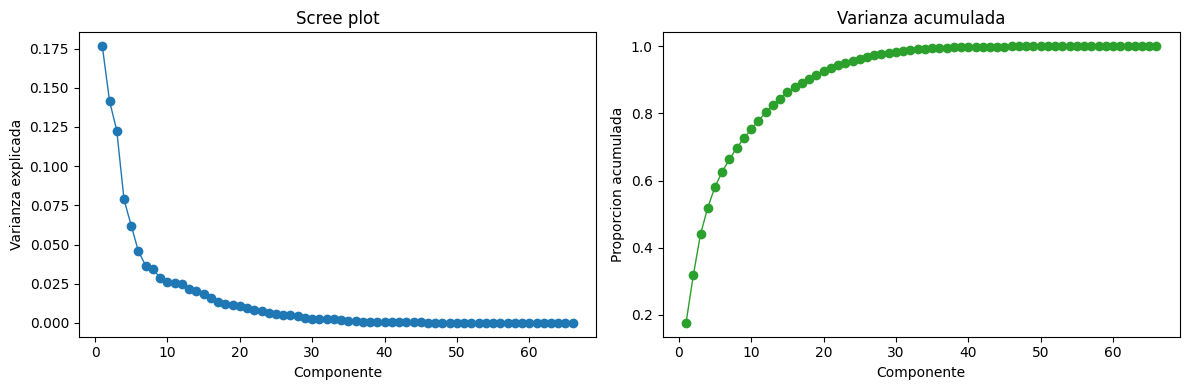

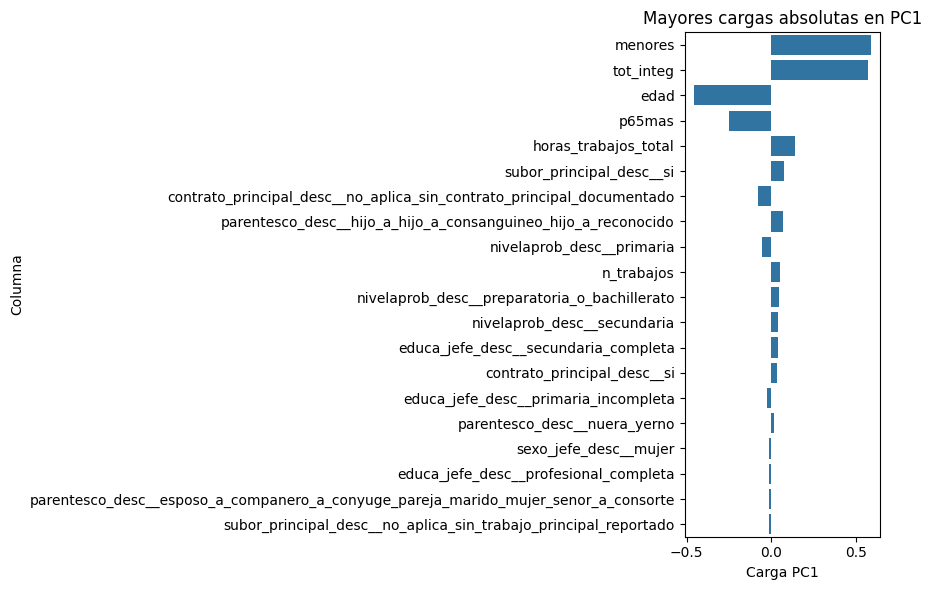

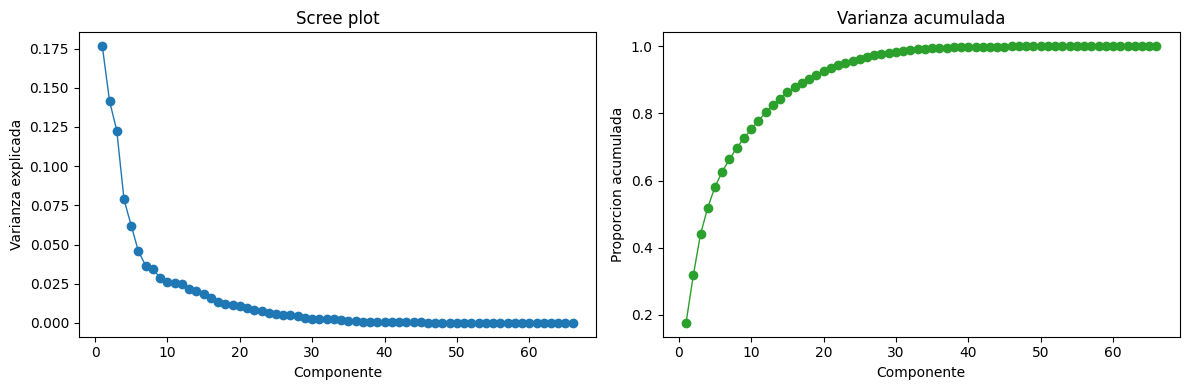

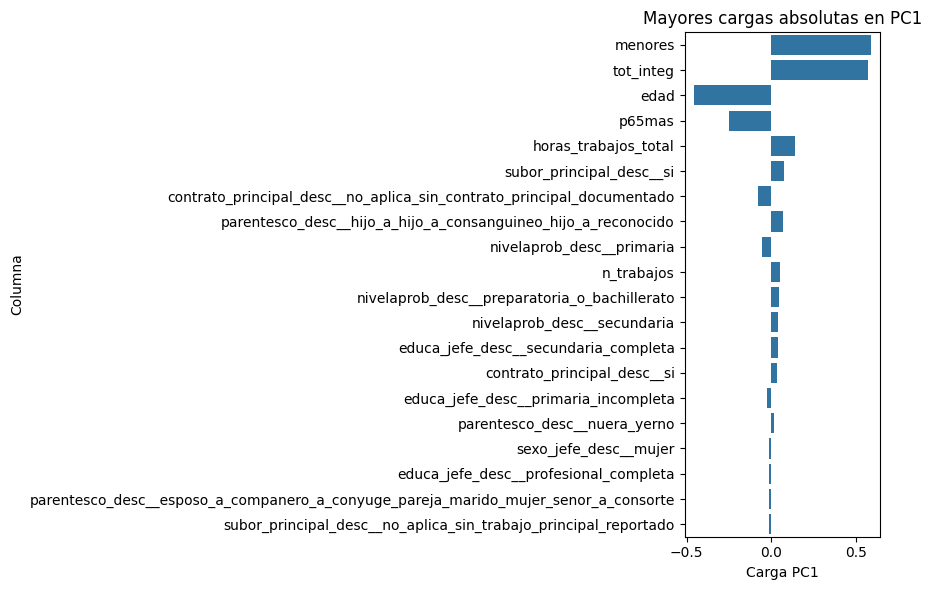

In [19]:
figuras_regresion = {}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(np.arange(1, len(varianza_pca)+1), varianza_pca["varianza_explicada"], marker="o", linewidth=1)
axes[0].set_title("Scree plot")
axes[0].set_xlabel("Componente")
axes[0].set_ylabel("Varianza explicada")
axes[1].plot(np.arange(1, len(varianza_pca)+1), varianza_pca["varianza_acumulada"], marker="o", linewidth=1, color="tab:green")
axes[1].set_title("Varianza acumulada")
axes[1].set_xlabel("Componente")
axes[1].set_ylabel("Proporcion acumulada")
fig.tight_layout()
figuras_regresion["pca_varianza"] = fig
display(fig)

top_cargas = cargas_pca.assign(abs_PC1=cargas_pca["PC1"].abs()).sort_values("abs_PC1", ascending=False).head(20)
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=top_cargas, y="columna_matriz", x="PC1", ax=ax)
ax.set_title("Mayores cargas absolutas en PC1")
ax.set_xlabel("Carga PC1")
ax.set_ylabel("Columna")
fig.tight_layout()
figuras_regresion["pca_cargas_pc1"] = fig
display(fig)


## 17. Arbol diagnostico, metricas e importancias


In [20]:
modelo_arbol = fit_decision_tree(X_train, y_train, max_depth=TREE_MAX_DEPTH, min_samples_leaf=TREE_MIN_SAMPLES_LEAF, random_state=RANDOM_STATE)
pred_train_arbol = modelo_arbol.predict(X_train)
pred_valid_arbol = modelo_arbol.predict(X_valid)
metricas_arbol = pd.DataFrame([regression_metrics(y_train, pred_train_arbol, scale_name="arbol_ingreso_nominal", split="entrenamiento"), regression_metrics(y_valid, pred_valid_arbol, scale_name="arbol_ingreso_nominal", split="validacion")])
importancias_impureza = aggregate_column_importance(modelo_arbol.feature_importances_, column_info)
display(metricas_arbol)
display(importancias_impureza.head(20))


,escala,particion,n,mae,rmse
0,arbol_ingreso_nominal,entrenamiento,113173,16097.544661,66159.917373
1,arbol_ingreso_nominal,validacion,28406,15977.223589,41997.042370


,variable_original,importancia_impureza
0,contrato_principal_desc,0.374140
1,educa_jefe_desc,0.292511
2,horas_trabajos_total,0.156678
3,subor_principal_desc,0.056978
4,sexo_desc,0.039987
5,segsoc_desc,0.036589
6,edad,0.022263
7,region_banxico,0.011686
8,nivelaprob_desc,0.009168
9,p65mas,0.000000


## 18. Permutacion conjunta por variable original en validacion


In [21]:
importancias_permutacion_detalle, importancias_permutacion = permutation_importance_by_block(modelo_arbol, X_valid, y_valid, column_info, n_repeats=PERMUTATION_REPEATS, random_state=RANDOM_STATE)
importancias_permutacion.head(20)


,variable_original,delta_rmse_media,delta_rmse_sd,delta_rmse_min,delta_rmse_max,delta_mae_media,delta_mae_sd,delta_mae_min,delta_mae_max,repeticiones
0,educa_jefe_desc,1708.233060,40.844153,1637.823099,1767.842209,1228.417520,32.767761,1191.829197,1277.288233,10
1,contrato_principal_desc,1663.923081,58.758973,1526.771705,1752.612498,2510.848068,35.999089,2425.477776,2553.213791,10
2,horas_trabajos_total,1217.621037,73.625414,1140.172396,1366.145374,2141.561629,38.196513,2093.652002,2202.365014,10
3,subor_principal_desc,306.879914,70.064737,185.769208,404.851689,46.915441,22.301995,10.394946,79.839891,10
4,segsoc_desc,290.194084,22.815498,244.552247,326.451103,882.207459,21.536584,848.343328,920.838750,10
5,sexo_desc,264.642834,19.506132,236.740067,297.221228,449.309334,11.562512,432.072039,475.321524,10
6,edad,141.089306,10.261310,119.735080,154.055354,149.993415,9.759155,133.074636,161.482530,10
7,region_banxico,128.712651,22.495373,96.882198,156.329074,248.576840,11.684867,233.446639,271.694728,10
8,nivelaprob_desc,54.778616,5.129240,47.444477,65.612091,82.862894,9.620434,73.853055,103.226413,10
9,p65mas,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10


## 19. Tabla de revision por variable


In [22]:
coef_por_variable = tabla_coeficientes_nominal.loc[tabla_coeficientes_nominal["variable_original"].ne("intercepto")].assign(abs_coef=lambda d: d["coeficiente"].abs()).groupby("variable_original", dropna=False).agg(max_abs_coef_nominal=("abs_coef", "max"), n_coeficientes=("coeficiente", "size")).reset_index()
vif_por_variable = tabla_vif.merge(column_info[["columna_matriz", "variable_original"]], on="columna_matriz", how="left").groupby("variable_original", dropna=False).agg(vif_max=("vif", "max")).reset_index()
cargas_por_variable = cargas_pca.assign(abs_PC1=cargas_pca["PC1"].abs()).groupby("variable_original", dropna=False).agg(carga_pc1_abs_max=("abs_PC1", "max")).reset_index()
tabla_revision_variables = tabla_variables.rename(columns={"variable":"variable_original"}).merge(coef_por_variable, on="variable_original", how="left").merge(vif_por_variable, on="variable_original", how="left").merge(tabla_gvif[["variable_original", "gvif", "gvif_ajustado", "estado"]].rename(columns={"estado":"estado_gvif"}), on="variable_original", how="left").merge(cargas_por_variable, on="variable_original", how="left").merge(importancias_impureza, on="variable_original", how="left").merge(importancias_permutacion[["variable_original", "delta_rmse_media", "delta_rmse_sd"]], on="variable_original", how="left")
tabla_revision_variables["decision"] = "pendiente_revision_conjunta"
tabla_revision_variables


,variable_original,tipo,estado,max_abs_coef_nominal,n_coeficientes,vif_max,gvif,gvif_ajustado,estado_gvif,carga_pc1_abs_max,importancia_impureza,delta_rmse_media,delta_rmse_sd,decision
0,edad,continua,seleccionada,55.385015,1,2.529877,2.529877,1.590559,ok,0.459235,0.022263,141.089306,10.261310,pendiente_revision_conjunta
1,n_trabajos,continua,seleccionada,232.848255,1,1.698079,1.698079,1.303104,ok,0.050362,0.000000,0.000000,0.000000,pendiente_revision_conjunta
2,horas_trabajos_total,continua,seleccionada,307.799468,1,1.454942,1.454942,1.206210,ok,0.143533,0.156678,1217.621037,73.625414,pendiente_revision_conjunta
3,tot_integ,continua,seleccionada,205.851854,1,2.138425,2.138425,1.462336,ok,0.571202,0.000000,0.000000,0.000000,pendiente_revision_conjunta
4,menores,continua,seleccionada,130.840911,1,2.014427,2.014427,1.419305,ok,0.591779,0.000000,0.000000,0.000000,pendiente_revision_conjunta
5,p65mas,continua,seleccionada,1764.409808,1,1.527542,1.527542,1.235938,ok,0.247600,0.000000,0.000000,0.000000,pendiente_revision_conjunta
6,sexo_desc,categorica,seleccionada,8145.745029,1,1.469256,1.469256,1.212129,ok,0.007937,0.039987,264.642834,19.506132,pendiente_revision_conjunta
7,nivelaprob_desc,categorica,seleccionada,51525.880351,10,12.711750,19.684022,1.160662,ok,0.056526,0.009168,54.778616,5.129240,pendiente_revision_conjunta
8,region_banxico,categorica,seleccionada,7444.531962,3,1.583048,1.220948,1.033831,ok,0.004000,0.011686,128.712651,22.495373,pendiente_revision_conjunta
9,tam_loc_desc,categorica,seleccionada,3822.236001,3,1.627745,1.372451,1.054183,ok,0.011203,0.000000,0.000000,0.000000,pendiente_revision_conjunta


## 20. Figuras de regresion y residuos


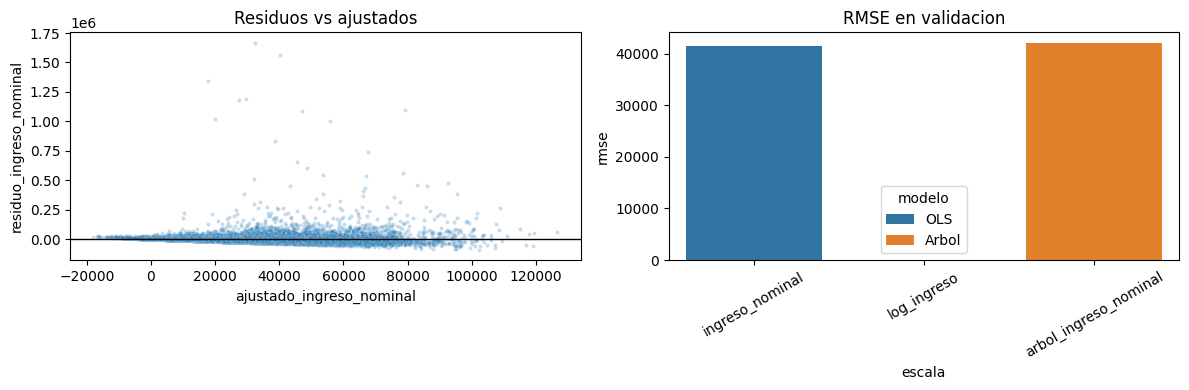

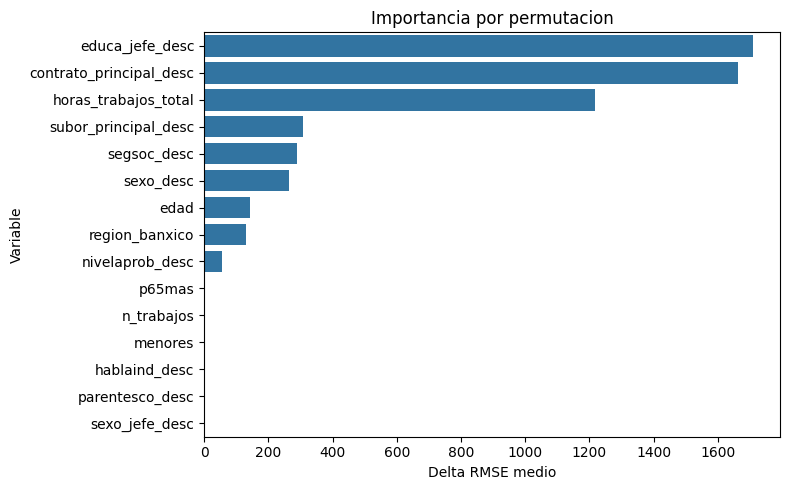

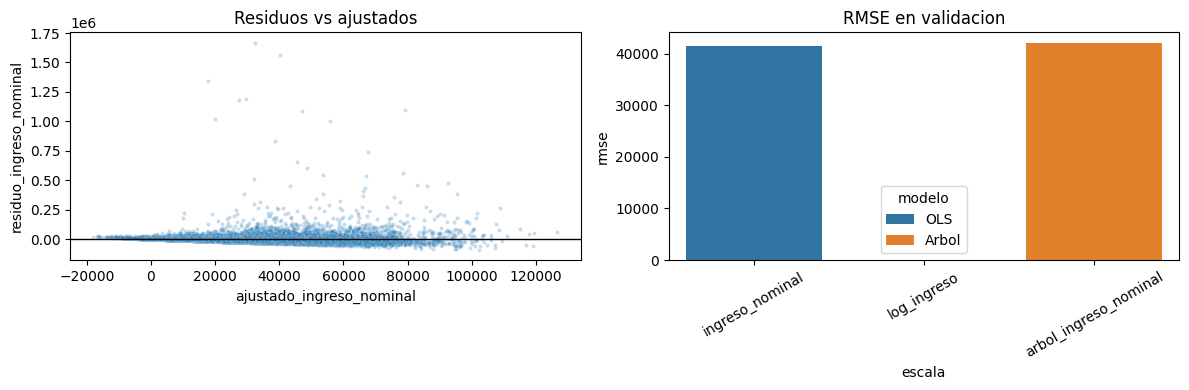

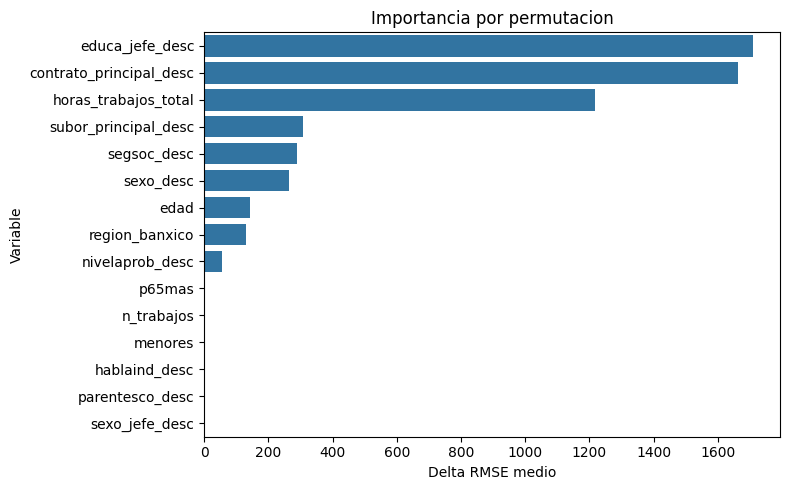

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
muestra_residuos = residuos_train.sample(n=min(20000, len(residuos_train)), random_state=RANDOM_STATE)
sns.scatterplot(data=muestra_residuos, x="ajustado_ingreso_nominal", y="residuo_ingreso_nominal", s=8, alpha=0.25, ax=axes[0])
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Residuos vs ajustados")
metricas_plot = pd.concat([metricas_regresion.assign(modelo="OLS"), metricas_arbol.assign(modelo="Arbol")], ignore_index=True)
sns.barplot(data=metricas_plot.loc[metricas_plot["particion"].eq("validacion")], x="escala", y="rmse", hue="modelo", ax=axes[1])
axes[1].tick_params(axis="x", rotation=30)
axes[1].set_title("RMSE en validacion")
fig.tight_layout()
figuras_regresion["regresion_residuos_metricas"] = fig
display(fig)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=importancias_permutacion.head(15), y="variable_original", x="delta_rmse_media", ax=ax)
ax.set_title("Importancia por permutacion")
ax.set_xlabel("Delta RMSE medio")
ax.set_ylabel("Variable")
fig.tight_layout()
figuras_regresion["arbol_permutacion"] = fig
display(fig)


## 21. Decisiones pendientes


In [24]:
decisiones_pendientes = pd.DataFrame([
    {"decision":"escala_principal", "estado":"pendiente", "nota":"Elegir ingreso nominal o log ingreso requiere revision sustantiva."},
    {"decision":"stepwise", "estado":"pendiente_no_ejecutado", "nota":"No hay criterio aprobado."},
    {"decision":"seleccion_supervisada", "estado":"pendiente_no_ejecutado", "nota":"Ninguna variable se elimina automaticamente."},
    {"decision":"regresion_reducida", "estado":"pendiente_no_ejecutado", "nota":"Depende de revision conjunta."},
    {"decision":"PCR", "estado":"pendiente_no_ejecutado", "nota":"No se selecciona numero de componentes ni se ajusta PCR."},
    {"decision":"est_socio_desc", "estado":"pendiente", "nota":variables_pendientes["est_socio_desc"]},
    {"decision":"tam_emp_principal_desc", "estado":"pendiente", "nota":variables_pendientes["tam_emp_principal_desc"]},
])
decisiones_pendientes


,decision,estado,nota
0,escala_principal,pendiente,Elegir ingreso nominal o log ingreso requiere ...
1,stepwise,pendiente_no_ejecutado,No hay criterio aprobado.
2,seleccion_supervisada,pendiente_no_ejecutado,Ninguna variable se elimina automaticamente.
3,regresion_reducida,pendiente_no_ejecutado,Depende de revision conjunta.
4,PCR,pendiente_no_ejecutado,No se selecciona numero de componentes ni se a...
5,est_socio_desc,pendiente,Contexto socioeconomico; requiere decision sus...
6,tam_emp_principal_desc,pendiente,Pendiente por dependencia estructural potencia...


## 22. Objetos finales en memoria


In [25]:
objetos_finales = pd.DataFrame([
    {"objeto":"base_determinantes", "tipo":type(base_determinantes).__name__, "filas":len(base_determinantes), "columnas":base_determinantes.shape[1]},
    {"objeto":"train", "tipo":type(train).__name__, "filas":len(train), "columnas":train.shape[1]},
    {"objeto":"valid", "tipo":type(valid).__name__, "filas":len(valid), "columnas":valid.shape[1]},
    {"objeto":"variables_candidatas", "tipo":type(variables_candidatas).__name__, "filas":len(variables_candidatas), "columnas":"lista"},
    {"objeto":"variables_seleccionadas", "tipo":type(variables_seleccionadas).__name__, "filas":len(variables_seleccionadas), "columnas":"lista"},
    {"objeto":"encoder", "tipo":type(encoder).__name__, "filas":len(encoder), "columnas":"diccionario"},
    {"objeto":"X_train", "tipo":type(X_train).__name__, "filas":X_train.shape[0], "columnas":X_train.shape[1]},
    {"objeto":"X_valid", "tipo":type(X_valid).__name__, "filas":X_valid.shape[0], "columnas":X_valid.shape[1]},
    {"objeto":"y_train", "tipo":type(y_train).__name__, "filas":len(y_train), "columnas":"serie"},
    {"objeto":"y_valid", "tipo":type(y_valid).__name__, "filas":len(y_valid), "columnas":"serie"},
    {"objeto":"modelo_ols_nominal", "tipo":type(modelo_ols_nominal).__name__, "filas":len(modelo_ols_nominal), "columnas":"diccionario"},
    {"objeto":"modelo_ols_log", "tipo":type(modelo_ols_log).__name__, "filas":len(modelo_ols_log), "columnas":"diccionario"},
    {"objeto":"predicciones", "tipo":type(predicciones).__name__, "filas":len(predicciones), "columnas":predicciones.shape[1]},
    {"objeto":"metricas_regresion", "tipo":type(metricas_regresion).__name__, "filas":len(metricas_regresion), "columnas":metricas_regresion.shape[1]},
    {"objeto":"tabla_coeficientes", "tipo":type(tabla_coeficientes).__name__, "filas":len(tabla_coeficientes), "columnas":tabla_coeficientes.shape[1]},
    {"objeto":"diagnosticos_residuos", "tipo":type(diagnosticos_residuos).__name__, "filas":len(diagnosticos_residuos), "columnas":diagnosticos_residuos.shape[1]},
    {"objeto":"tabla_vif", "tipo":type(tabla_vif).__name__, "filas":len(tabla_vif), "columnas":tabla_vif.shape[1]},
    {"objeto":"tabla_gvif", "tipo":type(tabla_gvif).__name__, "filas":len(tabla_gvif), "columnas":tabla_gvif.shape[1]},
    {"objeto":"matriz_pca_train", "tipo":type(matriz_pca_train).__name__, "filas":matriz_pca_train.shape[0], "columnas":matriz_pca_train.shape[1]},
    {"objeto":"matriz_pca_valid", "tipo":type(matriz_pca_valid).__name__, "filas":matriz_pca_valid.shape[0], "columnas":matriz_pca_valid.shape[1]},
    {"objeto":"modelo_pca", "tipo":type(modelo_pca).__name__, "filas":getattr(modelo_pca, "n_components_", "pendiente"), "columnas":"modelo"},
    {"objeto":"scores_pca", "tipo":type(scores_pca).__name__, "filas":len(scores_pca), "columnas":"diccionario"},
    {"objeto":"varianza_pca", "tipo":type(varianza_pca).__name__, "filas":len(varianza_pca), "columnas":varianza_pca.shape[1]},
    {"objeto":"cargas_pca", "tipo":type(cargas_pca).__name__, "filas":len(cargas_pca), "columnas":cargas_pca.shape[1]},
    {"objeto":"modelo_arbol", "tipo":type(modelo_arbol).__name__, "filas":1, "columnas":"modelo"},
    {"objeto":"importancias_impureza", "tipo":type(importancias_impureza).__name__, "filas":len(importancias_impureza), "columnas":importancias_impureza.shape[1]},
    {"objeto":"importancias_permutacion", "tipo":type(importancias_permutacion).__name__, "filas":len(importancias_permutacion), "columnas":importancias_permutacion.shape[1]},
    {"objeto":"tabla_revision_variables", "tipo":type(tabla_revision_variables).__name__, "filas":len(tabla_revision_variables), "columnas":tabla_revision_variables.shape[1]},
])
objetos_finales


,objeto,tipo,filas,columnas
0,base_determinantes,DataFrame,141579,39
1,train,DataFrame,113173,40
2,valid,DataFrame,28406,40
3,variables_candidatas,list,17,lista
4,variables_seleccionadas,list,17,lista
5,encoder,dict,4,diccionario
6,X_train,DataFrame,113173,66
7,X_valid,DataFrame,28406,66
8,y_train,Series,113173,serie
9,y_valid,Series,28406,serie


## 23. Exportacion opcional final


In [ ]:
if EXPORTAR_RESULTADOS:
    TABLE_DIR.mkdir(parents=True, exist_ok=True)
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    LOCAL_DIR.mkdir(parents=True, exist_ok=True)
    tablas_regresion = {
        "configuracion_efectiva":configuracion_efectiva,
        "variables_candidatas":tabla_variables,
        "variables_pendientes":pd.DataFrame([{"variable":k, "motivo":v} for k, v in variables_pendientes.items()]),
        "variables_excluidas_manual":pd.DataFrame({"variable":variables_excluidas_manual}),
        "validaciones_entrada":validaciones_entrada,
        "particion_resumen":resumen_particion,
        "particion_validaciones":validacion_particion,
        "matriz_regresion_columnas":column_info,
        "referencias_ohe_entrenamiento":referencias_entrenamiento,
        "categorias_no_vistas_por_particion":categorias_no_vistas,
        "validaciones_matriz":validaciones_matriz,
        "fit_ols_resumen":pd.concat([fit_nominal, fit_log], ignore_index=True),
        "metricas_regresion":metricas_regresion,
        "coeficientes_ols":tabla_coeficientes,
        "residuos_resumen":diagnosticos_residuos,
        "observaciones_influyentes_sin_identificadores":observaciones_influyentes,
        "dependencia_matriz":dependencia_matriz,
        "dependencia_matriz_detalle":detalle_dependencia_matriz,
        "vif_columnas":tabla_vif,
        "gvif_variables":tabla_gvif,
        "validacion_vif_gvif":validacion_vif_gvif,
        "pca_parametros_preprocesamiento":parametros_pca,
        "pca_varianza":varianza_pca,
        "pca_cargas":cargas_pca,
        "pca_correlaciones_scores_target":correlaciones_scores_target,
        "arbol_metricas":metricas_arbol,
        "arbol_importancias_impureza":importancias_impureza,
        "arbol_importancias_permutacion_detalle":importancias_permutacion_detalle,
        "arbol_importancias_permutacion":importancias_permutacion,
        "revision_variables":tabla_revision_variables,
        "decisiones_pendientes":decisiones_pendientes,
    }
    for nombre, tabla in tablas_regresion.items():
        tabla.to_csv(TABLE_DIR / f"{nombre}.csv", index=False, encoding="utf-8")
    hogares.to_csv(LOCAL_DIR / f"particion_hogares_{ANIO_ANALISIS}.csv.gz", index=False, compression="gzip")
    pd.DataFrame({"columna":X_train.columns}).to_csv(LOCAL_DIR / "columnas_X_entrenamiento.csv", index=False, encoding="utf-8")
    figuras_generadas = []
    for nombre, figura in figuras_regresion.items():
        ruta = FIGURE_DIR / f"{nombre}.png"
        figura.savefig(ruta, dpi=160, bbox_inches="tight")
        figuras_generadas.append({"figura":nombre, "archivo":str(ruta), "origen":"objeto_en_memoria"})
        plt.close(figura)
    figuras_generadas_df = pd.DataFrame(figuras_generadas)
    figuras_generadas_df.to_csv(TABLE_DIR / "figuras_generadas.csv", index=False, encoding="utf-8")
    manifest_regresion = {
        "etapa":13,
        "nombre":f"regresion_diagnostico_determinantes_{ANIO_ANALISIS}_{ESPECIFICACION}",
        "estado":"pendiente_ejecucion_manual",
        "codigo_refactorizado_por_codex":True,
        "codex_ejecuto_notebook":False,
        "notebook_ejecutado":False,
        "configuracion":configuracion_efectiva.to_dict(orient="records"),
        "entrada_base_interpretable":str(BASE_PATH),
        "contrato":"leer base interpretable de notebook 12; no reconstruir universo desde mart; ajustar preprocesadores solo con entrenamiento",
        "salidas_tablas":{n:str(TABLE_DIR / f"{n}.csv") for n in tablas_regresion},
        "salidas_figuras":figuras_generadas_df.to_dict(orient="records"),
        "salidas_locales_fuera_git":{"particion_hogares":str(LOCAL_DIR / f"particion_hogares_{ANIO_ANALISIS}.csv.gz"), "columnas_X_entrenamiento":str(LOCAL_DIR / "columnas_X_entrenamiento.csv")},
        "variables_candidatas":variables_candidatas,
        "variables_seleccionadas":variables_seleccionadas,
        "variables_excluidas_manual":variables_excluidas_manual,
        "variables_pendientes":variables_pendientes,
        "referencias_ohe_entrenamiento":referencias_entrenamiento.to_dict(orient="records"),
        "categorias_no_vistas":categorias_no_vistas.to_dict(orient="records"),
        "validaciones":{"entrada":validaciones_entrada.to_dict(orient="records"), "particion":validacion_particion.to_dict(orient="records"), "matriz":validaciones_matriz.to_dict(orient="records")},
        "limitaciones":["Diagnostico no ponderado, sin diseno muestral formal.", "No hay seleccion automatica, regresion reducida ni PCR.", "La escala principal del target sigue pendiente.", "No interpretar importancias o coeficientes como causalidad."],
    }
    (TABLE_DIR / "manifest_regresion_diagnostico.json").write_text(json.dumps(manifest_regresion, ensure_ascii=False, indent=2), encoding="utf-8")
else:
    figuras_generadas_df = pd.DataFrame(columns=["figura", "archivo", "origen"])
    manifest_regresion = {"estado":"no_exportado", "motivo":"EXPORTAR_RESULTADOS=False"}

pd.DataFrame([
    {"elemento":"exportacion", "estado":"realizada" if EXPORTAR_RESULTADOS else "omitida"},
    {"elemento":"manifest", "estado":manifest_regresion["estado"]},
    {"elemento":"tablas", "ruta":str(TABLE_DIR) if EXPORTAR_RESULTADOS else "no exportadas"},
    {"elemento":"figuras", "ruta":str(FIGURE_DIR) if EXPORTAR_RESULTADOS else "no exportadas"},
])
